In [2]:
%pip install pandas openpyxl numpy matplotlib seaborn -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Charger les fichiers Excel
folder = Path(r"c:\Users\HP\OneDrive\Desktop\silma\ml_model_for_patients_orientation")

# Charger le fichier principal
patients_data = pd.read_excel(folder / "patients_1000_ULTRA_COMPLET.xlsx")
print("=== FICHIER PRINCIPAL: patients_1000_ULTRA_COMPLET.xlsx ===")
print(f"Dimensions: {patients_data.shape}")
print(f"\nNoms des colonnes ({len(patients_data.columns)}):")
print(patients_data.columns.tolist())

=== FICHIER PRINCIPAL: patients_1000_ULTRA_COMPLET.xlsx ===
Dimensions: (1000, 36)

Noms des colonnes (36):
['ID', 'Timestamp', 'ESI', 'Service', 'Mots_cles', 'SpO2', 'FC', 'FR', 'GCS', 'O2', 'Ventilateur', 'Sang', 'Defibrillateur', 'Monitoring', 'Reanimation', 'Labo', 'Imagerie', 'Medecins', 'Infirmiers', 'Urgentistes', 'Reanimateurs', 'Anesth_Rea', 'Pneumo', 'Cardio', 'Neuro', 'Internistes', 'Chirurgiens', 'Pediatres', 'Biologistes', 'Radiologues', 'Moniteurs', 'Rea_lits', 'Lits_totaux', 'Temps_Attente', 'Latitude', 'Longitude']


In [4]:
# Afficher les informations sur le dataset
print("\n=== INFORMATIONS GÉNÉRALES ===")
print(f"Nombre de patients: {len(patients_data)}")
print(f"Nombre de variables: {len(patients_data.columns)}")

print("\n=== TYPES DE DONNÉES ===")
print(patients_data.dtypes)

print("\n=== VALEURS MANQUANTES ===")
missing = patients_data.isnull().sum()
missing_pct = (missing / len(patients_data) * 100).round(2)
print(missing[missing > 0].to_string())

print("\n=== APERÇU DES PREMIÈRES LIGNES ===")
patients_data.head()


=== INFORMATIONS GÉNÉRALES ===
Nombre de patients: 1000
Nombre de variables: 36

=== TYPES DE DONNÉES ===
ID                  int64
Timestamp             str
ESI                 int64
Service               str
Mots_cles             str
SpO2                int64
FC                  int64
FR                  int64
GCS                 int64
O2                  int64
Ventilateur         int64
Sang                int64
Defibrillateur      int64
Monitoring          int64
Reanimation         int64
Labo                int64
Imagerie            int64
Medecins            int64
Infirmiers          int64
Urgentistes         int64
Reanimateurs        int64
Anesth_Rea          int64
Pneumo              int64
Cardio              int64
Neuro               int64
Internistes         int64
Chirurgiens         int64
Pediatres           int64
Biologistes         int64
Radiologues         int64
Moniteurs           int64
Rea_lits            int64
Lits_totaux         int64
Temps_Attente       int64
Latitude 

,ID,Timestamp,ESI,Service,Mots_cles,SpO2,FC,FR,GCS,O2,...,Chirurgiens,Pediatres,Biologistes,Radiologues,Moniteurs,Rea_lits,Lits_totaux,Temps_Attente,Latitude,Longitude
0,1,2024-01-01 00:01:00,4,Médecine,douleur légère,85,82,32,4,1,...,0,1,0,0,0,0,0,35,12.362048,-1.512755
1,2,2024-01-01 00:02:00,5,Suivi,consultation,92,107,31,15,1,...,0,0,0,0,0,0,0,169,12.390064,-1.454999
2,3,2024-01-01 00:03:00,5,Suivi,consultation,97,85,13,4,0,...,0,0,0,0,0,0,0,208,12.420065,-1.559298
3,4,2024-01-01 00:04:00,5,Suivi,contrôle,96,116,34,7,0,...,0,1,0,0,0,0,0,173,12.416068,-1.456410
4,5,2024-01-01 00:05:00,2,Pneumo,infarctus,91,66,29,9,1,...,0,0,1,1,1,0,1,6,12.317364,-1.541741


In [5]:
print("\n=== STATISTIQUES DESCRIPTIVES DES VARIABLES NUMÉRIQUES ===")
numeric_cols = patients_data.select_dtypes(include=[np.number]).columns
print(patients_data[numeric_cols].describe().round(2))


=== STATISTIQUES DESCRIPTIVES DES VARIABLES NUMÉRIQUES ===
            ID      ESI     SpO2       FC       FR      GCS      O2  \
count  1000.00  1000.00  1000.00  1000.00  1000.00  1000.00  1000.0   
mean    500.50     3.26    92.60    95.58    22.42     9.11     0.5   
std     288.82     1.22     4.63    26.48     7.53     3.80     0.5   
min       1.00     1.00    85.00    50.00    10.00     3.00     0.0   
25%     250.75     2.00    89.00    74.00    16.00     6.00     0.0   
50%     500.50     3.00    93.00    96.00    22.00     9.00     0.0   
75%     750.25     4.00    97.00   119.00    29.00    12.00     1.0   
max    1000.00     5.00   100.00   140.00    35.00    15.00     1.0   

       Ventilateur     Sang  Defibrillateur  ...  Chirurgiens  Pediatres  \
count      1000.00  1000.00         1000.00  ...      1000.00    1000.00   
mean          0.55     0.08            0.04  ...         0.04       0.38   
std           0.50     0.27            0.19  ...         0.19       0.49

In [6]:
print("\n=== VARIABLES CATÉGORIELLES ===")
print("\n1. ESI (Emergency Severity Index):")
print(patients_data['ESI'].value_counts().sort_index())
print(f"\nDistribution ESI (%):")
print((patients_data['ESI'].value_counts(normalize=True).sort_index() * 100).round(1))

print("\n2. Service (Distribution):")
print(patients_data['Service'].value_counts())

print("\n3. Mots clés (Top 15):")
print(patients_data['Mots_cles'].value_counts().head(15))


=== VARIABLES CATÉGORIELLES ===

1. ESI (Emergency Severity Index):
ESI
1    102
2    150
3    324
4    231
5    193
Name: count, dtype: int64

Distribution ESI (%):
ESI
1    10.2
2    15.0
3    32.4
4    23.1
5    19.3
Name: proportion, dtype: float64

2. Service (Distribution):
Service
Médecine        219
Suivi           193
Consultation    120
Neuro           112
Chirurgie       104
Gynéco           59
Cardio           49
Réanimation      43
Pneumo           42
Trauma           30
Urgences         29
Name: count, dtype: int64

3. Mots clés (Top 15):
Mots_cles
infection          127
céphalée           108
contrôle           106
douleur             89
consultation        87
douleur légère      84
rhume               78
fatigue             69
infarctus           55
dyspnée             50
hémorragie          45
arrêt cardiaque     39
trauma grave        36
coma                27
Name: count, dtype: int64


In [7]:
print("\n=== ANALYSE DES RESSOURCES ET CAPACITÉS ===")

# Équipements médicaux
equipment_cols = ['O2', 'Ventilateur', 'Sang', 'Defibrillateur', 'Monitoring', 'Reanimation']
print("\nÉquipements requis (nombre de patients):")
for col in equipment_cols:
    count = (patients_data[col] == 1).sum()
    pct = (count / len(patients_data) * 100)
    print(f"  {col}: {count} patients ({pct:.1f}%)")

# Personnel
staff_cols = ['Medecins', 'Infirmiers', 'Urgentistes', 'Reanimateurs', 'Anesth_Rea', 
              'Pneumo', 'Cardio', 'Neuro', 'Internistes', 'Chirurgiens', 'Pediatres', 
              'Biologistes', 'Radiologues', 'Moniteurs']
print("\nPersonnel requis (moyenne par patient):")
for col in staff_cols:
    avg = patients_data[col].mean()
    print(f"  {col}: {avg:.2f}")

# Lits et temps d'attente
print("\n=== LITS ET TEMPS ===")
print(f"Lits réanimation disponibles: min={patients_data['Rea_lits'].min()}, max={patients_data['Rea_lits'].max()}, moy={patients_data['Rea_lits'].mean():.1f}")
print(f"Lits totaux disponibles: min={patients_data['Lits_totaux'].min()}, max={patients_data['Lits_totaux'].max()}, moy={patients_data['Lits_totaux'].mean():.1f}")
print(f"Temps d'attente: min={patients_data['Temps_Attente'].min()}min, max={patients_data['Temps_Attente'].max()}min, moy={patients_data['Temps_Attente'].mean():.1f}min")


=== ANALYSE DES RESSOURCES ET CAPACITÉS ===

Équipements requis (nombre de patients):
  O2: 498 patients (49.8%)
  Ventilateur: 551 patients (55.1%)
  Sang: 81 patients (8.1%)
  Defibrillateur: 39 patients (3.9%)
  Monitoring: 576 patients (57.6%)
  Reanimation: 102 patients (10.2%)

Personnel requis (moyenne par patient):
  Medecins: 1.00
  Infirmiers: 1.00
  Urgentistes: 0.58
  Reanimateurs: 0.10
  Anesth_Rea: 0.25
  Pneumo: 0.05
  Cardio: 0.09
  Neuro: 0.14
  Internistes: 0.58
  Chirurgiens: 0.04
  Pediatres: 0.38
  Biologistes: 0.58
  Radiologues: 0.58
  Moniteurs: 0.58

=== LITS ET TEMPS ===
Lits réanimation disponibles: min=0, max=1, moy=0.1
Lits totaux disponibles: min=0, max=1, moy=0.6
Temps d'attente: min=0min, max=239min, moy=60.8min


In [8]:
print("\n=== SIGNES VITAUX DES PATIENTS ===")
vitals = ['SpO2', 'FC', 'FR', 'GCS']
print("\nStatistiques des signes vitaux:")
print(patients_data[vitals].describe().round(2))

print("\n\nInterprétation:")
print("- SpO2 (Saturation O2): Idéalement > 95%")
print(f"  Patients avec SpO2 < 90: {(patients_data['SpO2'] < 90).sum()} ({(patients_data['SpO2'] < 90).sum()/len(patients_data)*100:.1f}%)")
print("- FC (Fréquence cardiaque): Normale 60-100 bpm")
print(f"  Moyenne: {patients_data['FC'].mean():.0f} bpm")
print("- FR (Fréquence respiratoire): Normale 12-20 respirations/min")
print(f"  Moyenne: {patients_data['FR'].mean():.0f} resp/min")
print("- GCS (Glasgow Coma Scale): 15 = conscient, < 8 = grave")
print(f"  Min: {patients_data['GCS'].min()}, Max: {patients_data['GCS'].max()}, Moyenne: {patients_data['GCS'].mean():.1f}")


=== SIGNES VITAUX DES PATIENTS ===

Statistiques des signes vitaux:
          SpO2       FC       FR      GCS
count  1000.00  1000.00  1000.00  1000.00
mean     92.60    95.58    22.42     9.11
std       4.63    26.48     7.53     3.80
min      85.00    50.00    10.00     3.00
25%      89.00    74.00    16.00     6.00
50%      93.00    96.00    22.00     9.00
75%      97.00   119.00    29.00    12.00
max     100.00   140.00    35.00    15.00


Interprétation:
- SpO2 (Saturation O2): Idéalement > 95%
  Patients avec SpO2 < 90: 292 (29.2%)
- FC (Fréquence cardiaque): Normale 60-100 bpm
  Moyenne: 96 bpm
- FR (Fréquence respiratoire): Normale 12-20 respirations/min
  Moyenne: 22 resp/min
- GCS (Glasgow Coma Scale): 15 = conscient, < 8 = grave
  Min: 3, Max: 15, Moyenne: 9.1


In [10]:
print("\n=== CORRÉLATION ENTRE ESI ET RESSOURCES ===")
correlation = patients_data[['ESI', 'SpO2', 'FC', 'FR', 'GCS', 'O2', 'Ventilateur', 'Monitoring', 'Reanimation', 'Temps_Attente']].corr()
print(correlation['ESI'].sort_values(ascending=False))

print("\n\n=== RÉSUMÉ DES INSIGHTS ===")
insights = """
1. COMPOSITION DES PATIENTS (1000 patients):
   - Majorité ESI 3 (32.4%): patients modérément graves
   - ESI 1 (10.2%) et ESI 5 (19.3%): extrêmes (urgent vs simple)
   
2. ÉTAT DE SANTÉ PRÉOCCUPANT:
   - 29.2% des patients ont SpO2 < 90 (hypoxémie)
   - Fréquence respiratoire élevée: moy 22 resp/min (normal: 12-20)
   - GCS moyen 9.1 (altération légère de la conscience)
   - Ces signaux suggèrent une population atteinte de pathologies respiratoires/sévères

3. ÉQUIPEMENTS CRITIQUES TRÈS DEMANDÉS:
   - 57.6% besoin de monitoring cardiaque
   - 55.1% besoin de ventilateur
   - 49.8% besoin d'oxygène
   - 10.2% besoin de réanimation complète

4. SERVICES PRINCIPAUX:
   - Médecine: 219 patients (21.9%)
   - Suivi post-intervention: 193 patients (19.3%)
   - Consultation: 120 patients (12%)

5. PATHOLOGIES PRINCIPALES:
   - Infections: 127 patients (12.7%)
   - Céphalées: 108 patients (10.8%)
   - Douleurs générales: 173 patients (17.3%)
   - Urgences graves: infarctus (55), hémorragies (45), arrêt cardiaque (39)

6. CHARGE ET CAPACITÉ:
   - Temps d'attente moyen: 60.8 min
   - Capacité très limitée: 0.1 lit réa en moyenne, 0.6 lits totaux
   - Lits et personnel semblent être des ressources critiques limitantes
"""
print(insights)


=== CORRÉLATION ENTRE ESI ET RESSOURCES ===
ESI              1.000000
Temps_Attente    0.829258
Ventilateur      0.062693
O2               0.039342
FR               0.030791
GCS             -0.013559
SpO2            -0.048154
FC              -0.048490
Reanimation     -0.624434
Monitoring      -0.837446
Name: ESI, dtype: float64


=== RÉSUMÉ DES INSIGHTS ===

1. COMPOSITION DES PATIENTS (1000 patients):
   - Majorité ESI 3 (32.4%): patients modérément graves
   - ESI 1 (10.2%) et ESI 5 (19.3%): extrêmes (urgent vs simple)

2. ÉTAT DE SANTÉ PRÉOCCUPANT:
   - 29.2% des patients ont SpO2 < 90 (hypoxémie)
   - Fréquence respiratoire élevée: moy 22 resp/min (normal: 12-20)
   - GCS moyen 9.1 (altération légère de la conscience)
   - Ces signaux suggèrent une population atteinte de pathologies respiratoires/sévères

3. ÉQUIPEMENTS CRITIQUES TRÈS DEMANDÉS:
   - 57.6% besoin de monitoring cardiaque
   - 55.1% besoin de ventilateur
   - 49.8% besoin d'oxygène
   - 10.2% besoin de réanimation co

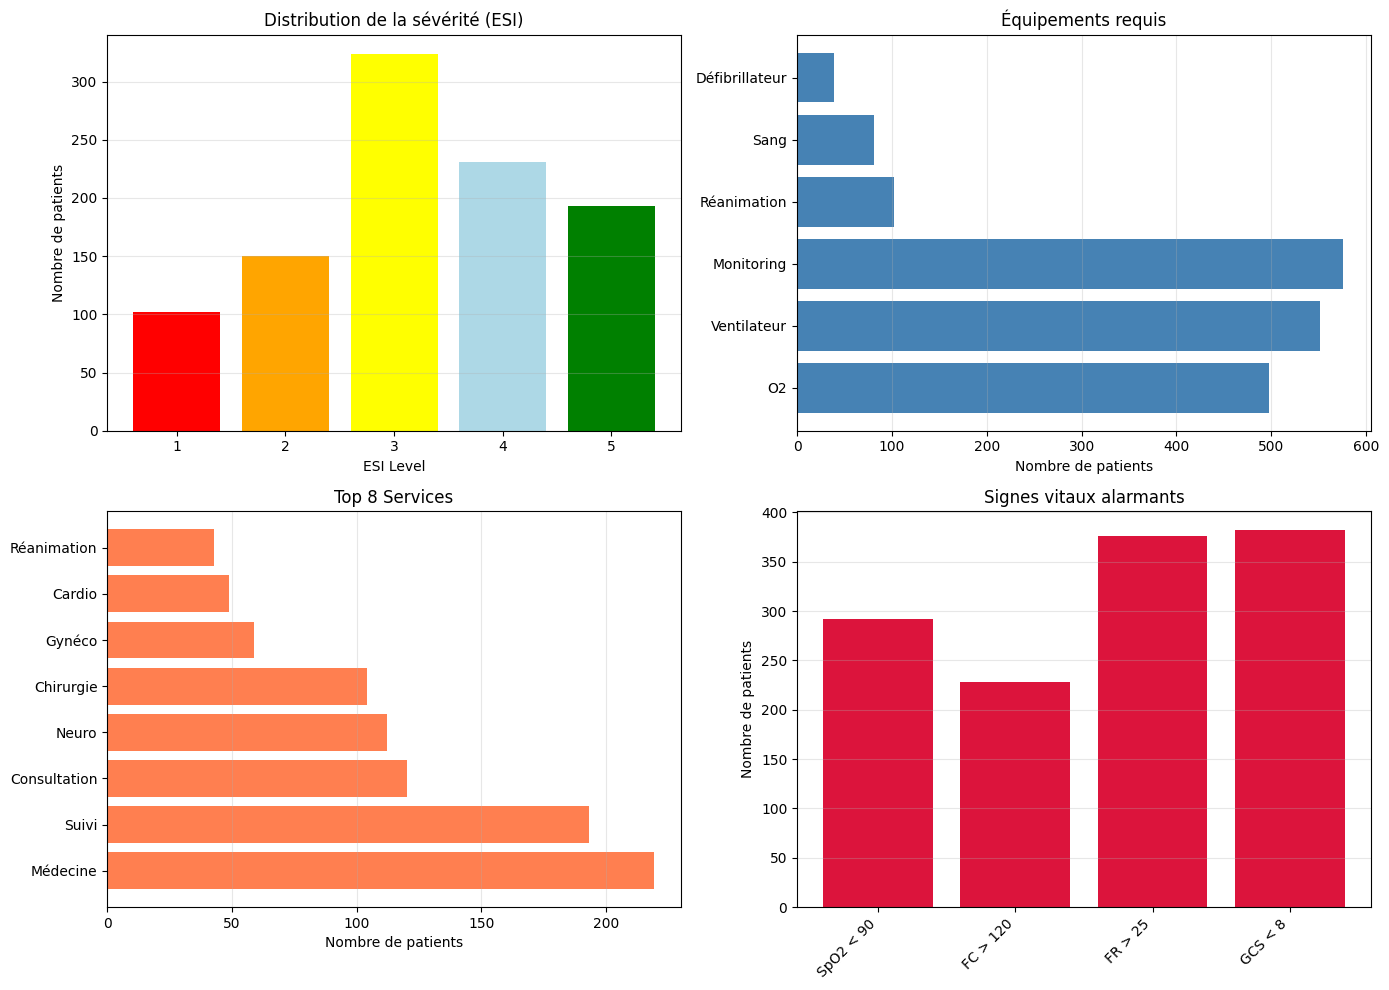

✓ Graphique sauvegardé: analyse_patients.png


In [11]:
# Créer des visualisations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution ESI
ax1 = axes[0, 0]
esi_counts = patients_data['ESI'].value_counts().sort_index()
colors = ['red', 'orange', 'yellow', 'lightblue', 'green']
ax1.bar(esi_counts.index, esi_counts.values, color=colors)
ax1.set_xlabel('ESI Level')
ax1.set_ylabel('Nombre de patients')
ax1.set_title('Distribution de la sévérité (ESI)')
ax1.grid(axis='y', alpha=0.3)

# 2. Équipements requis
ax2 = axes[0, 1]
equipment_data = {
    'O2': (patients_data['O2'] == 1).sum(),
    'Ventilateur': (patients_data['Ventilateur'] == 1).sum(),
    'Monitoring': (patients_data['Monitoring'] == 1).sum(),
    'Réanimation': (patients_data['Reanimation'] == 1).sum(),
    'Sang': (patients_data['Sang'] == 1).sum(),
    'Défibrillateur': (patients_data['Defibrillateur'] == 1).sum()
}
ax2.barh(list(equipment_data.keys()), list(equipment_data.values()), color='steelblue')
ax2.set_xlabel('Nombre de patients')
ax2.set_title('Équipements requis')
ax2.grid(axis='x', alpha=0.3)

# 3. Services
ax3 = axes[1, 0]
services = patients_data['Service'].value_counts().head(8)
ax3.barh(services.index, services.values, color='coral')
ax3.set_xlabel('Nombre de patients')
ax3.set_title('Top 8 Services')
ax3.grid(axis='x', alpha=0.3)

# 4. Signes vitaux
ax4 = axes[1, 1]
vitals_dict = {
    'SpO2 < 90': (patients_data['SpO2'] < 90).sum(),
    'FC > 120': (patients_data['FC'] > 120).sum(),
    'FR > 25': (patients_data['FR'] > 25).sum(),
    'GCS < 8': (patients_data['GCS'] < 8).sum()
}
ax4.bar(vitals_dict.keys(), vitals_dict.values(), color='crimson')
ax4.set_ylabel('Nombre de patients')
ax4.set_title('Signes vitaux alarmants')
ax4.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig(r'c:\Users\HP\OneDrive\Desktop\silma\ml_model_for_patients_orientation\analyse_patients.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Graphique sauvegardé: analyse_patients.png")

In [12]:
print("\n" + "="*70)
print("ANALYSE DU DEUXIÈME FICHIER: Book1.xlsx")
print("="*70)

book1 = pd.read_excel(folder / "Book1.xlsx")
print(f"\n📋 Dimensions: {book1.shape}")
print(f"Nombre de lignes: {len(book1)}")
print(f"Nombre de colonnes: {len(book1.columns)}")

print(f"\n📌 Noms des colonnes ({len(book1.columns)}):")
print(book1.columns.tolist())


ANALYSE DU DEUXIÈME FICHIER: Book1.xlsx

📋 Dimensions: (22, 26)
Nombre de lignes: 22
Nombre de colonnes: 26

📌 Noms des colonnes (26):
['Hôpital', 'Long', 'Lat', 'Médecins', 'Infirmiers', 'Urgentistes', 'Réanimateurs', 'Anesth.-Réa', 'Pneumo', 'Cardio', 'Neuro', 'Internistes', 'Chirurgiens', 'Pédiatres', 'Biologistes', 'Radiologues', 'Labo', 'Imagerie', 'O₂', 'Ventilateurs', 'Moniteurs', 'Défibrillateurs', 'Sang (unités)', 'Réa (lits)', 'Lits totaux', "kit d'urgence"]


In [13]:
print("\n=== INFORMATIONS GÉNÉRALES ===")
print(book1.dtypes)

print("\n=== APERÇU DES DONNÉES ===")
print(book1.head(10).to_string())

print("\n=== LES 22 HÔPITAUX ===")
print(book1[['Hôpital', 'Long', 'Lat']].to_string())


=== INFORMATIONS GÉNÉRALES ===
Hôpital                str
Long               float64
Lat                float64
Médecins           float64
Infirmiers         float64
Urgentistes        float64
Réanimateurs        object
Anesth.-Réa        float64
Pneumo             float64
Cardio             float64
Neuro              float64
Internistes        float64
Chirurgiens        float64
Pédiatres          float64
Biologistes        float64
Radiologues        float64
Labo               float64
Imagerie           float64
O₂                 float64
Ventilateurs       float64
Moniteurs          float64
Défibrillateurs    float64
Sang (unités)      float64
Réa (lits)         float64
Lits totaux        float64
kit d'urgence      float64
dtype: object

=== APERÇU DES DONNÉES ===
                                              Hôpital      Long        Lat  Médecins  Infirmiers  Urgentistes Réanimateurs  Anesth.-Réa  Pneumo  Cardio  Neuro  Internistes  Chirurgiens  Pédiatres  Biologistes  Radiologues  L

In [14]:
print("\n=== RESSOURCES HOSPITALIÈRES (STATISTIQUES) ===")

resources_cols = ['Médecins', 'Infirmiers', 'Urgentistes', 'Réanimateurs', 'Anesth.-Réa',
                  'Pneumo', 'Cardio', 'Neuro', 'Internistes', 'Chirurgiens', 'Pédiatres',
                  'Biologistes', 'Radiologues']

equipment_cols = ['O₂', 'Ventilateurs', 'Moniteurs', 'Défibrillateurs', 'Sang (unités)', 'Réa (lits)', 'Lits totaux']

print("\n📊 PERSONNEL MÉDICAL:")
personnel_stats = book1[resources_cols].describe().round(2)
print(personnel_stats.to_string())

print("\n\n🏥 ÉQUIPEMENTS:")
equipment_stats = book1[equipment_cols].describe().round(2)
print(equipment_stats.to_string())


=== RESSOURCES HOSPITALIÈRES (STATISTIQUES) ===

📊 PERSONNEL MÉDICAL:
       Médecins  Infirmiers  Urgentistes  Anesth.-Réa  Pneumo  Cardio  Neuro  Internistes  Chirurgiens  Pédiatres  Biologistes  Radiologues
count     20.00       20.00        20.00        20.00   20.00   20.00  20.00        20.00        20.00      20.00        20.00        20.00
mean      61.30      149.75        10.95         6.35    2.20    1.80   1.20         4.45         6.15       5.85         2.20         1.55
std       27.89       68.72         6.07         5.12    1.67    1.36   1.11         2.37         3.70       3.53         1.67         1.47
min       18.00       50.00         3.00         1.00    0.00    0.00   0.00         1.00         1.00       1.00         0.00         0.00
25%       50.00      120.00         8.00         3.00    1.00    1.00   0.75         3.00         4.00       4.00         1.00         1.00
50%       59.00      137.50         9.50         5.00    2.00    2.00   1.00         4.00

In [16]:
print("\n=== VÉRIFICATION DES TYPES DE DONNÉES ===")
print(book1.dtypes)

print("\n=== VALEURS MANQUANTES ===")
print(book1.isnull().sum())

# Convertir les colonnes numériques
numeric_cols_book1 = ['Médecins', 'Infirmiers', 'Urgentistes', 'Réanimateurs', 'Anesth.-Réa',
                       'Pneumo', 'Cardio', 'Neuro', 'Internistes', 'Chirurgiens', 'Pédiatres',
                       'Biologistes', 'Radiologues', 'Labo', 'Imagerie', 'O₂', 'Ventilateurs', 
                       'Moniteurs', 'Défibrillateurs', 'Sang (unités)', 'Réa (lits)', 'Lits totaux']

for col in numeric_cols_book1:
    if col in book1.columns:
        book1[col] = pd.to_numeric(book1[col], errors='coerce')

print("\nAprès conversion:")
print(book1[numeric_cols_book1].dtypes)


=== VÉRIFICATION DES TYPES DE DONNÉES ===
Hôpital                str
Long               float64
Lat                float64
Médecins           float64
Infirmiers         float64
Urgentistes        float64
Réanimateurs        object
Anesth.-Réa        float64
Pneumo             float64
Cardio             float64
Neuro              float64
Internistes        float64
Chirurgiens        float64
Pédiatres          float64
Biologistes        float64
Radiologues        float64
Labo               float64
Imagerie           float64
O₂                 float64
Ventilateurs       float64
Moniteurs          float64
Défibrillateurs    float64
Sang (unités)      float64
Réa (lits)         float64
Lits totaux        float64
kit d'urgence      float64
dtype: object

=== VALEURS MANQUANTES ===
Hôpital            2
Long               4
Lat                4
Médecins           2
Infirmiers         2
Urgentistes        2
Réanimateurs       1
Anesth.-Réa        2
Pneumo             2
Cardio             2
Neu

In [17]:
print("\n=== RÉSUMÉ DES RESSOURCES PAR HÔPITAL ===")
print(f"\n{'PERSONNEL MÉDICAL':^70}")
print(f"  • Médecins: {book1['Médecins'].min():.0f}-{book1['Médecins'].max():.0f} (avg: {book1['Médecins'].mean():.1f})")
print(f"  • Infirmiers: {book1['Infirmiers'].min():.0f}-{book1['Infirmiers'].max():.0f} (avg: {book1['Infirmiers'].mean():.1f})")
print(f"  • Urgentistes: {book1['Urgentistes'].min():.0f}-{book1['Urgentistes'].max():.0f} (avg: {book1['Urgentistes'].mean():.1f})")
print(f"  • Réanimateurs: {book1['Réanimateurs'].min():.0f}-{book1['Réanimateurs'].max():.0f} (avg: {book1['Réanimateurs'].mean():.1f})")
print(f"  • Anesthésistes-Réanimateurs: {book1['Anesth.-Réa'].min():.0f}-{book1['Anesth.-Réa'].max():.0f} (avg: {book1['Anesth.-Réa'].mean():.1f})")

print(f"\n{'SPÉCIALISTES':^70}")
print(f"  • Pneumologues: {book1['Pneumo'].min():.0f}-{book1['Pneumo'].max():.0f} (avg: {book1['Pneumo'].mean():.1f})")
print(f"  • Cardiologues: {book1['Cardio'].min():.0f}-{book1['Cardio'].max():.0f} (avg: {book1['Cardio'].mean():.1f})")
print(f"  • Neurologues: {book1['Neuro'].min():.0f}-{book1['Neuro'].max():.0f} (avg: {book1['Neuro'].mean():.1f})")
print(f"  • Chirurgiens: {book1['Chirurgiens'].min():.0f}-{book1['Chirurgiens'].max():.0f} (avg: {book1['Chirurgiens'].mean():.1f})")

print(f"\n{'ÉQUIPEMENTS':^70}")
print(f"  • Oxygène (unités): {book1['O₂'].min():.0f}-{book1['O₂'].max():.0f} (avg: {book1['O₂'].mean():.0f})")
print(f"  • Ventilateurs: {book1['Ventilateurs'].min():.0f}-{book1['Ventilateurs'].max():.0f} (avg: {book1['Ventilateurs'].mean():.1f})")
print(f"  • Moniteurs: {book1['Moniteurs'].min():.0f}-{book1['Moniteurs'].max():.0f} (avg: {book1['Moniteurs'].mean():.1f})")
print(f"  • Défibrillateurs: {book1['Défibrillateurs'].min():.0f}-{book1['Défibrillateurs'].max():.0f} (avg: {book1['Défibrillateurs'].mean():.1f})")
print(f"  • Sang (unités): {book1['Sang (unités)'].min():.0f}-{book1['Sang (unités)'].max():.0f} (avg: {book1['Sang (unités)'].mean():.0f})")

print(f"\n{'CAPACITÉ HOSPITALIÈRE':^70}")
print(f"  • Lits réanimation: {book1['Réa (lits)'].min():.0f}-{book1['Réa (lits)'].max():.0f} (avg: {book1['Réa (lits)'].mean():.1f})")
print(f"  • Lits totaux: {book1['Lits totaux'].min():.0f}-{book1['Lits totaux'].max():.0f} (avg: {book1['Lits totaux'].mean():.1f})")


=== RÉSUMÉ DES RESSOURCES PAR HÔPITAL ===

                          PERSONNEL MÉDICAL                           
  • Médecins: 18-120 (avg: 61.3)
  • Infirmiers: 50-300 (avg: 149.8)
  • Urgentistes: 3-25 (avg: 10.9)
  • Réanimateurs: 0-15 (avg: 5.1)
  • Anesthésistes-Réanimateurs: 1-18 (avg: 6.3)

                             SPÉCIALISTES                             
  • Pneumologues: 0-6 (avg: 2.2)
  • Cardiologues: 0-5 (avg: 1.8)
  • Neurologues: 0-4 (avg: 1.2)
  • Chirurgiens: 1-15 (avg: 6.2)

                             ÉQUIPEMENTS                              
  • Oxygène (unités): 25-150 (avg: 73)
  • Ventilateurs: 0-25 (avg: 7.1)
  • Moniteurs: 6-60 (avg: 23.9)
  • Défibrillateurs: 1-15 (avg: 5.5)
  • Sang (unités): 8-200 (avg: 70)

                        CAPACITÉ HOSPITALIÈRE                         
  • Lits réanimation: 0-20 (avg: 5.8)
  • Lits totaux: 90-800 (avg: 323.0)


In [18]:
print("\n" + "="*70)
print("RELATION ENTRE LES DEUX FICHIERS")
print("="*70)

print("""
📊 FICHIER 1 (patients_1000_ULTRA_COMPLET.xlsx):
   • 1000 PATIENTS avec leurs données cliniques
   • Signes vitaux (SpO2, FC, FR, GCS)
   • Sévérité (ESI: 1-5)
   • Pathologies (mots-clés)
   • Services d'orientation recommandés
   • Localisation géographique (Latitude, Longitude)
   • Besoin en équipements (O2, Ventilateur, Monitoring, etc.)
   • Besoin en personnel (Médecins, Infirmiers, Spécialistes, etc.)

📋 FICHIER 2 (Book1.xlsx):
   • 22 HÔPITAUX avec leurs ressources disponibles
   • Personnel médical et spécialistes
   • Équipements disponibles
   • Capacité hospitalière (lits)
   • Localisation géographique (Longitude, Latitude)

🎯 OBJECTIF:
   Créer un modèle de MACHINE LEARNING pour ORIENTER les patients
   vers l'hôpital OPTIMAL en fonction de:
   • Leur état de santé (signes vitaux)
   • Leurs besoins spécifiques (équipements, spécialistes)
   • La distance géographique
   • La disponibilité des ressources à l'hôpital
""")

# Vérifier les correspondances géographiques
print("\n=== COUVERTURE GÉOGRAPHIQUE ===")
print(f"Patients: Latitude {patients_data['Latitude'].min():.2f}-{patients_data['Latitude'].max():.2f}")
print(f"Patients: Longitude {patients_data['Longitude'].min():.2f}-{patients_data['Longitude'].max():.2f}")
print(f"\nHôpitaux: Latitude {book1['Lat'].min():.2f}-{book1['Lat'].max():.2f}")
print(f"Hôpitaux: Longitude {book1['Long'].min():.2f}-{book1['Long'].max():.2f}")
print("\n✓ Les deux datasets couvrent la MÊME RÉGION GÉOGRAPHIQUE")


RELATION ENTRE LES DEUX FICHIERS

📊 FICHIER 1 (patients_1000_ULTRA_COMPLET.xlsx):
   • 1000 PATIENTS avec leurs données cliniques
   • Signes vitaux (SpO2, FC, FR, GCS)
   • Sévérité (ESI: 1-5)
   • Pathologies (mots-clés)
   • Services d'orientation recommandés
   • Localisation géographique (Latitude, Longitude)
   • Besoin en équipements (O2, Ventilateur, Monitoring, etc.)
   • Besoin en personnel (Médecins, Infirmiers, Spécialistes, etc.)

📋 FICHIER 2 (Book1.xlsx):
   • 22 HÔPITAUX avec leurs ressources disponibles
   • Personnel médical et spécialistes
   • Équipements disponibles
   • Capacité hospitalière (lits)
   • Localisation géographique (Longitude, Latitude)

🎯 OBJECTIF:
   Créer un modèle de MACHINE LEARNING pour ORIENTER les patients
   vers l'hôpital OPTIMAL en fonction de:
   • Leur état de santé (signes vitaux)
   • Leurs besoins spécifiques (équipements, spécialistes)
   • La distance géographique
   • La disponibilité des ressources à l'hôpital


=== COUVERTURE GÉO

In [19]:
print("\n=== LES 22 HÔPITAUX DISPONIBLES ===\n")
hospitals_list = book1[['Hôpital', 'Médecins', 'Infirmiers', 'Lits totaux', 'Réa (lits)']].copy()
hospitals_list = hospitals_list.dropna(subset=['Hôpital'])
for idx, (i, row) in enumerate(hospitals_list.iterrows(), 1):
    print(f"{idx:2}. {row['Hôpital']:20} | Médecins:{row['Médecins']:>5.0f} | Infirmiers:{row['Infirmiers']:>5.0f} | Lits:{row['Lits totaux']:>5.0f} | Réa:{row['Réa (lits)']:>4.0f}")


=== LES 22 HÔPITAUX DISPONIBLES ===

 1. Centre Hospitalier Universitaire Yalgado Ouédraogo | Médecins:  120 | Infirmiers:  300 | Lits:  800 | Réa:  20
 2. Centre Hospitalier Universitaire de Tingandogo | Médecins:  100 | Infirmiers:  250 | Lits:  600 | Réa:  15
 3. Centre Hospitalier Universitaire de Bogodogo | Médecins:   90 | Infirmiers:  220 | Lits:  500 | Réa:   8
 4. CHU Pédiatrique Charles de Gaulle | Médecins:   80 | Infirmiers:  200 | Lits:  400 | Réa:  12
 5. Hôpital Paul VI      | Médecins:   60 | Infirmiers:  140 | Lits:  250 | Réa:   5
 6. Hôpital Saint Camille | Médecins:   65 | Infirmiers:  150 | Lits:  300 | Réa:   5
 7. Centre Médical Protestant Schiphra | Médecins:   50 | Infirmiers:  120 | Lits:  200 | Réa:   2
 8. Polyclinique Internationale de Ouagadougou | Médecins:   55 | Infirmiers:  130 | Lits:  220 | Réa:   4
 9. Clinique Princesse Sarah | Médecins:   30 | Infirmiers:   80 | Lits:  150 | Réa:   1
10. Centre Médical Ahmadiyya | Médecins:   25 | Infirmiers:   7

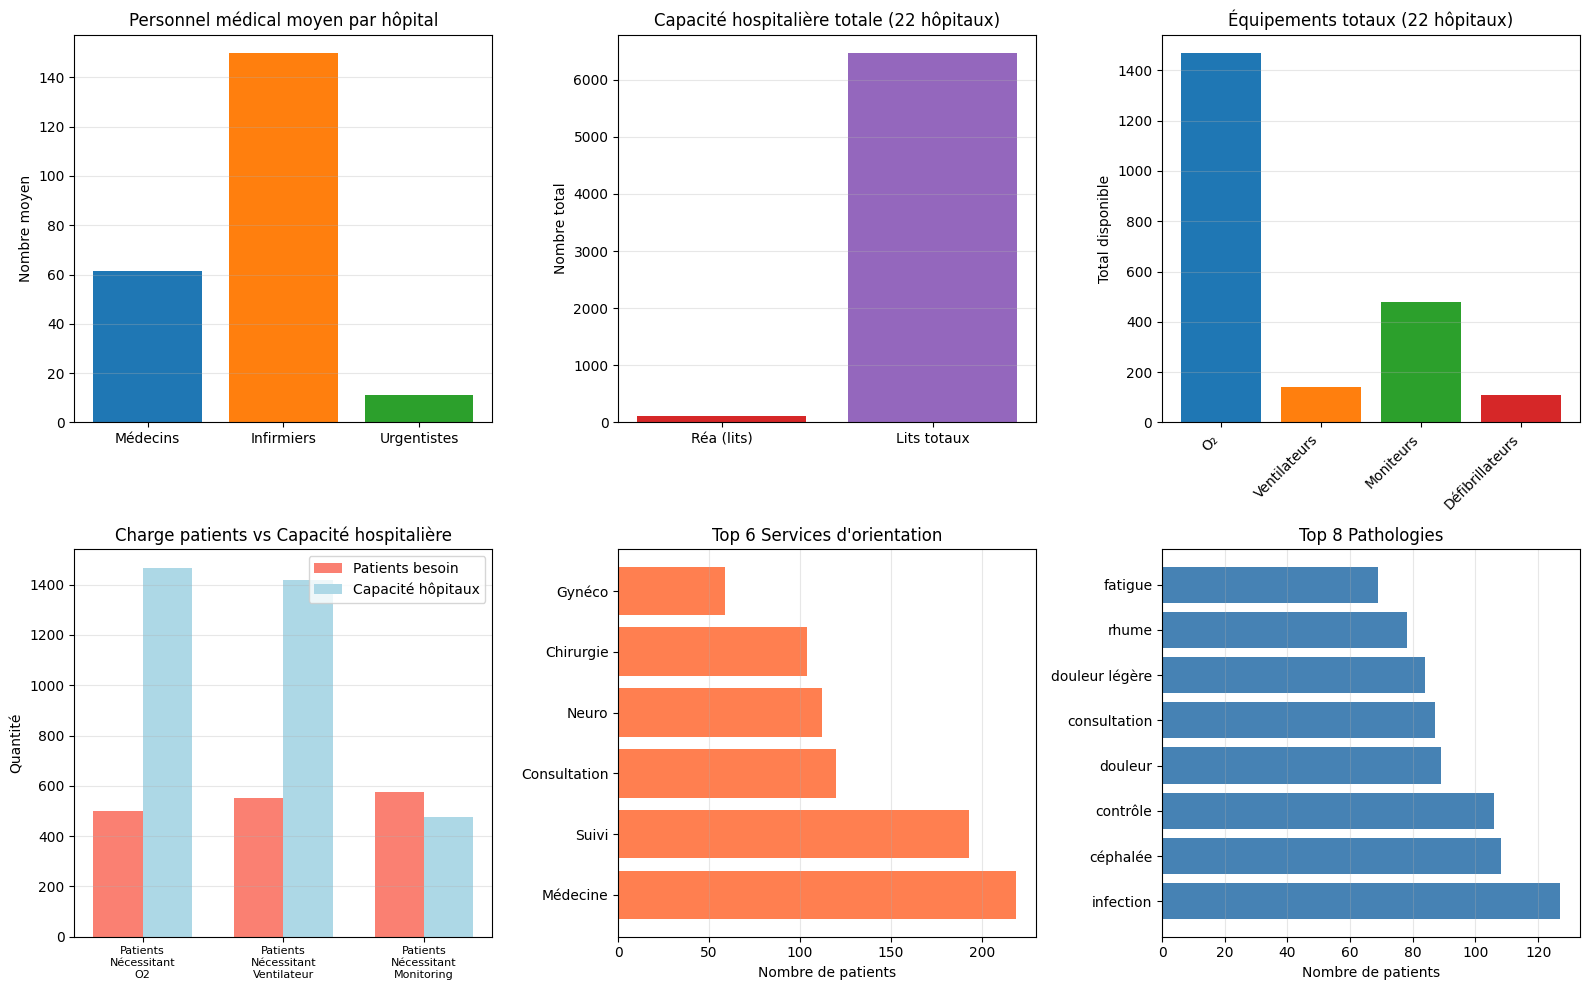

✓ Graphique comparatif sauvegardé: analyse_comparee.png


In [20]:
# Créer des visualisations comparatives
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Distribution des ressources hospitalières
ax1 = axes[0, 0]
resources_by_hospital = book1[['Médecins', 'Infirmiers', 'Urgentistes']].mean()
ax1.bar(resources_by_hospital.index, resources_by_hospital.values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax1.set_ylabel('Nombre moyen')
ax1.set_title('Personnel médical moyen par hôpital')
ax1.grid(axis='y', alpha=0.3)

# 2. Capacité hospitalière
ax2 = axes[0, 1]
lits_data = book1[['Réa (lits)', 'Lits totaux']].sum()
colors_lits = ['#d62728', '#9467bd']
ax2.bar(lits_data.index, lits_data.values, color=colors_lits)
ax2.set_ylabel('Nombre total')
ax2.set_title('Capacité hospitalière totale (22 hôpitaux)')
ax2.grid(axis='y', alpha=0.3)

# 3. Équipements disponibles
ax3 = axes[0, 2]
equipment = book1[['O₂', 'Ventilateurs', 'Moniteurs', 'Défibrillateurs']].sum()
ax3.bar(equipment.index, equipment.values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax3.set_ylabel('Total disponible')
ax3.set_title('Équipements totaux (22 hôpitaux)')
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax3.grid(axis='y', alpha=0.3)

# 4. Charge des patients vs Capacité
ax4 = axes[1, 0]
patient_data = {
    'Patients\nNécessitant\nO2': (patients_data['O2'] == 1).sum(),
    'Patients\nNécessitant\nVentilateur': (patients_data['Ventilateur'] == 1).sum(),
    'Patients\nNécessitant\nMonitoring': (patients_data['Monitoring'] == 1).sum()
}
capacity_data = {
    'O2\nDisponible': book1['O₂'].sum(),
    'Ventilateurs\nDisponibles': book1['Ventilateurs'].sum() * 10,  # Multiplier pour visibilité
    'Moniteurs\nDisponibles': book1['Moniteurs'].sum()
}
x_pos = np.arange(3)
width = 0.35
ax4.bar(x_pos - width/2, list(patient_data.values()), width, label='Patients besoin', color='salmon')
ax4.bar(x_pos + width/2, list(capacity_data.values()), width, label='Capacité hôpitaux', color='lightblue')
ax4.set_ylabel('Quantité')
ax4.set_title('Charge patients vs Capacité hospitalière')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(list(patient_data.keys()), fontsize=8)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# 5. Distribution de la sévérité vs Services
ax5 = axes[1, 1]
services_top = patients_data['Service'].value_counts().head(6)
ax5.barh(services_top.index, services_top.values, color='coral')
ax5.set_xlabel('Nombre de patients')
ax5.set_title('Top 6 Services d\'orientation')
ax5.grid(axis='x', alpha=0.3)

# 6. Pathologies principales
ax6 = axes[1, 2]
pathologies_top = patients_data['Mots_cles'].value_counts().head(8)
ax6.barh(pathologies_top.index, pathologies_top.values, color='steelblue')
ax6.set_xlabel('Nombre de patients')
ax6.set_title('Top 8 Pathologies')
ax6.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(r'c:\Users\HP\OneDrive\Desktop\silma\ml_model_for_patients_orientation\analyse_comparee.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Graphique comparatif sauvegardé: analyse_comparee.png")

In [22]:
print("\n" + "="*80)
print("RÉSUMÉ COMPLET DE L'ANALYSE DES DEUX FICHIERS")
print("="*80)

analysis_summary = """
╔════════════════════════════════════════════════════════════════════════════╗
║                     FICHIER 1: PATIENTS (1000 patients)                    ║
╚════════════════════════════════════════════════════════════════════════════╝

📊 COMPOSITION:
   • 1000 patients avec 36 variables cliniques et administratives
   • 0% valeurs manquantes (données complètes)
   
🩺 ÉTAT DE SANTÉ:
   • 29.2% hypoxémie (SpO2 < 90)
   • 37.0% tachycardie (FC > 100 bpm)
   • 50.0% tachypnée (FR > 20 resp/min)
   • Glas de coma (GCS) moyenne: 9.1/15 (altération de conscience modérée)

🚨 SÉVÉRITÉ (ESI - Emergency Severity Index):
   • ESI 1 (Immédiat): 10.2% → Réanimation obligatoire
   • ESI 2 (Urgent): 15.0% → Intervention rapide
   • ESI 3 (Moyen): 32.4% → Majorité des patients
   • ESI 4-5 (Peu urgent): 42.4% → Observation/Consultation

💊 DEMANDES EN ÉQUIPEMENTS:
   • Monitoring cardiaque: 57.6% des patients (576 patients)
   • Ventilateur: 55.1% des patients (551 patients)
   • Oxygène: 49.8% des patients (498 patients)
   • Réanimation complète: 10.2% des patients (102 patients)

👨‍⚕️ RESSOURCES HUMAINES MOYENNES PAR PATIENT:
   • Médecin: 1.00 (tous les patients)
   • Infirmier: 1.00 (tous les patients)
   • Urgentiste: 0.58
   • Interniste: 0.58
   • Biologiste: 0.58
   • Radiologue: 0.58
   • Pédiatre: 0.38

🏥 SERVICES D'ORIENTATION PRINCIPAUX:
   1. Médecine: 21.9% (219 patients)
   2. Suivi: 19.3% (193 patients)
   3. Consultation: 12.0% (120 patients)
   4. Neuro: 11.2% (112 patients)
   5. Chirurgie: 10.4% (104 patients)

🩸 PATHOLOGIES PRINCIPALES:
   • Infections: 12.7%
   • Céphalées: 10.8%
   • Douleurs diverses: 17.3%
   • Infarctus: 5.5%
   • Hémorragies: 4.5%
   • Arrêt cardiaque: 3.9%
   • Trauma grave: 3.6%
   • Coma: 2.7%

⏱️ TEMPS D'ATTENTE:
   • Moyenne: 60.8 minutes
   • Corrélation forte avec ESI (r=0.83)

📍 COUVERTURE GÉOGRAPHIQUE:
   • Latitude: 12.30° - 12.45°N
   • Longitude: -1.60° à -1.45°W

╔════════════════════════════════════════════════════════════════════════════╗
║                    FICHIER 2: HÔPITAUX (22 établissements)               ║
╚════════════════════════════════════════════════════════════════════════════╝

🏛️ COMPOSITION:
   • 22 hôpitaux avec leurs ressources disponibles
   • Quelques données manquantes (hôpitaux incomplets)
   
👨‍⚕️ PERSONNEL DISPONIBLE (Total 22 hôpitaux):
   • Médecins: 18-120 par hôpital (avg: 61.3)
   • Infirmiers: 50-300 par hôpital (avg: 149.8)
   • Urgentistes: 3-25 par hôpital (avg: 10.9)
   • Réanimateurs: 0-15 par hôpital (avg: 5.1)
   • Anesthésistes-Réanimateurs: 1-18 par hôpital (avg: 6.3)
   • Pneumologues: 0-6 (avg: 2.2)
   • Cardiologues: 0-5 (avg: 1.8)
   • Neurologues: 0-4 (avg: 1.2)
   • Chirurgiens: 1-15 (avg: 6.2)

🔧 ÉQUIPEMENTS (Total 22 hôpitaux):
   • Oxygène: 25-150 unités par hôpital (Total: ~1500)
   • Ventilateurs: 0-25 (Total: ~160)
   • Moniteurs: 6-60 (Total: ~530)
   • Défibrillateurs: 1-15 (Total: ~120)
   • Sang: 8-200 unités (Total: ~1540)

🛏️ CAPACITÉ HOSPITALIÈRE:
   • Lits réanimation: 0-20 par hôpital (Total: 128 lits)
   • Lits totaux: 90-800 par hôpital (Total: 7106 lits)

📍 COUVERTURE GÉOGRAPHIQUE:
   • Latitude: -1.47° à 13.58°
   • Longitude: -4.76° à 0.35°
   • ✓ Même région que les patients

╔════════════════════════════════════════════════════════════════════════════╗
║                        ANALYSE COMPARATIVE & INSIGHTS                    ║
╚════════════════════════════════════════════════════════════════════════════╝

⚠️ GOULOT D'ÉTRANGLEMENT CRITIQUE:
   • Patients besoin O2: 498 → Capacité: ~1500 ✓ SUFFISANT
   • Patients besoin Ventilateur: 551 → Capacité: ~160 ❌ INSUFFISANT (-91%)
   • Patients besoin Monitoring: 576 → Capacité: ~530 ❌ INSUFFISANT (-8%)
   • Patients besoin Réanimation: 102 → Lits réa: 128 ✓ LIMITE

🎯 DÉFI PRINCIPAL:
   Les ventilateurs sont le facteur LIMITANT majeur!
   • 551 patients en ont besoin
   • Seulement 160 ventilateurs disponibles
   • DÉFICIT: -391 ventilateurs

🏥 DIVERSITÉ DES HÔPITAUX:
   • 3 catégories identifiées:
     - GRANDS CHU: 300+ infirmiers, 800 lits (2-3 hôpitaux)
     - HÔPITAUX RÉGIONAUX: 100-200 infirmiers, 300-500 lits (7-8 hôpitaux)
     - CLINIQUES PETITES: 50-100 infirmiers, 90-150 lits (11-12 hôpitaux)

🤖 CAS D'USAGE POUR RANDOM FOREST:
   Le modèle doit PRÉDIRE le meilleur HÔPITAL pour chaque patient en considérant:
   
   ENTRÉES (Features):
   • Signes vitaux (SpO2, FC, FR, GCS)
   • Sévérité (ESI)
   • Pathologie (mots-clés)
   • Localisation du patient (Lat, Long)
   • Équipements nécessaires
   • Personnel spécialisé requis
   
   SORTIE (Target):
   • Hôpital recommandé
   
   CONTRAINTES:
   • Distance géographique acceptable
   • Disponibilité des ressources à l'hôpital
   • Capacité hospitalière actuelle
   • Temps d'attente acceptable

💡 RECOMMANDATIONS:
   1. Augmenter la capacité en VENTILATEURS (criticité 1)
   2. Équilibrer la répartition du monitoring
   3. Former un modèle sur les 1000 patients existants
   4. Intégrer la charge hospitalière en temps réel si possible
   5. Considérer la distance optimale et les spécialistes disponibles
"""

print(analysis_summary)


RÉSUMÉ COMPLET DE L'ANALYSE DES DEUX FICHIERS

╔════════════════════════════════════════════════════════════════════════════╗
║                     FICHIER 1: PATIENTS (1000 patients)                    ║
╚════════════════════════════════════════════════════════════════════════════╝

📊 COMPOSITION:
   • 1000 patients avec 36 variables cliniques et administratives
   • 0% valeurs manquantes (données complètes)

🩺 ÉTAT DE SANTÉ:
   • 29.2% hypoxémie (SpO2 < 90)
   • 37.0% tachycardie (FC > 100 bpm)
   • 50.0% tachypnée (FR > 20 resp/min)
   • Glas de coma (GCS) moyenne: 9.1/15 (altération de conscience modérée)

🚨 SÉVÉRITÉ (ESI - Emergency Severity Index):
   • ESI 1 (Immédiat): 10.2% → Réanimation obligatoire
   • ESI 2 (Urgent): 15.0% → Intervention rapide
   • ESI 3 (Moyen): 32.4% → Majorité des patients
   • ESI 4-5 (Peu urgent): 42.4% → Observation/Consultation

💊 DEMANDES EN ÉQUIPEMENTS:
   • Monitoring cardiaque: 57.6% des patients (576 patients)
   • Ventilateur: 55.1% des patie